# Federated IIoT Intrusion Detection System
GCN-BiGRU trained on CICIDS2017: centralized baseline vs. FedAvg with Dirichlet-partitioned non-IID clients.

**Pipeline:** data loading → sequence windows → 3-way split → GCN-BiGRU model → centralized training → federated training → comparison plots.

## Imports

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset

try:
    import matplotlib.pyplot as plt
    PLOTTING = True
except Exception as exc:
    print(f'Plotting disabled: {exc}')
    PLOTTING = False

from tqdm import tqdm

In [2]:
def train_test_split(X, y, test_size=0.25, random_state=None, stratify=None):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    y = np.asarray(y)
    if stratify is None:
        idx = rng.permutation(len(X))
        n_test = int(np.ceil(len(X) * test_size)) if 0 < test_size < 1 else int(test_size)
        test_idx = idx[:n_test]
        train_idx = idx[n_test:]
        return X[train_idx], X[test_idx], y[train_idx], y[test_idx]
    stratify = np.asarray(stratify)
    train_idx, test_idx = [], []
    for cls in np.unique(stratify):
        cls_idx = np.where(stratify == cls)[0]
        rng.shuffle(cls_idx)
        n_test = int(np.ceil(len(cls_idx) * test_size)) if 0 < test_size < 1 else int(test_size)
        test_idx.extend(cls_idx[:n_test].tolist())
        train_idx.extend(cls_idx[n_test:].tolist())
    train_idx = np.array(train_idx, dtype=np.int64)
    test_idx = np.array(test_idx, dtype=np.int64)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((y_true == y_pred).mean())


def precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0):
    if average != 'macro':
        raise NotImplementedError("Only average='macro' is supported in this notebook.")
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))
    precisions, recalls, f1s = [], [], []
    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        precision = tp / (tp + fp) if (tp + fp) else zero_division
        recall = tp / (tp + fn) if (tp + fn) else zero_division
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else zero_division
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(f1s)), None

## Paths & Device

In [3]:
ROOT        = Path.cwd()
DATA_DIR    = ROOT / 'data'
OUT_DIR     = ROOT / 'outputs'
DATASET_DIR = (ROOT / '../../dataset/cicids').resolve()

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')
print(f'Dataset  : {DATASET_DIR}')

Device   : cpu
Dataset  : /Users/ashishkalra/Library/CloudStorage/OneDrive-Personal/01_PhD_Research/Publications/dataset/cicids


## Hyperparameters

In [4]:
SEED          = 42
N_CLIENTS     = 10
NON_IID_ALPHA = 0.6
TEST_SIZE     = 0.20   # held-out test — evaluated once at the end
VAL_SIZE      = 0.10   # validation — used each epoch for model selection
MAX_SAMPLES   = 0      # 0 = use all rows

TIMESTEPS    = 1       # consecutive flow records per BiGRU window
HIDDEN       = 64      # GCN output / GRU base hidden units
EPOCHS       = 20      # centralized training epochs
BATCH        = 256
LR           = 1e-3
ROUNDS       = 10      # federated communication rounds
LOCAL_EPOCHS = 1       # local training epochs per federated round
EARLY_STOP_PATIENCE = 5   # stop centralized training if val_acc stagnates
NUM_WORKERS  = 2          # DataLoader worker processes (set 0 if multiprocessing causes issues)

---
## 1 · Data Loading

In [5]:
def find_label_column(columns):
    norm = {c.strip().lower(): c for c in columns}
    for key in ('label', 'class', 'target', 'attack', 'category'):
        if key in norm:
            return norm[key]
    for c in columns:
        if any(t in c.strip().lower() for t in ('label', 'class', 'target', 'attack')):
            return c
    return None

def map_to_binary_labels(raw_labels):
    s = raw_labels.fillna('').astype(str).str.strip().str.lower()
    is_benign = (
        s.isin({'0', '0.0', 'false', 'no', 'negative'})
        | s.str.contains('benign', regex=False)
        | s.str.contains('normal', regex=False)
    )
    return (~is_benign).astype(np.int64).to_numpy()

In [6]:
def _try_numpy_cache(dataset_dir, max_rows):
    cache_X    = DATA_DIR / 'raw_X.npy'
    cache_y    = DATA_DIR / 'raw_y.npy'
    cache_meta = DATA_DIR / 'raw_cache_meta.json'
    if not (cache_X.exists() and cache_y.exists() and cache_meta.exists()):
        return None
    with open(cache_meta) as f:
        m = json.load(f)
    if m.get('dataset_dir') == str(dataset_dir) and m.get('max_rows') == max_rows:
        print('load_cicids: numpy cache hit')
        return np.load(cache_X), np.load(cache_y), m['feature_names'], m['n_csv_files']
    return None

In [7]:
def _load_csvs_to_arrays(dataset_dir, max_rows, seed=SEED):
    csv_files = sorted(dataset_dir.rglob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found under {dataset_dir}')
    frames = []
    for path in csv_files:
        df = pd.read_csv(path, low_memory=False)
        df.columns = df.columns.str.strip()
        label_col = find_label_column(df.columns)
        if label_col is None:
            raise ValueError(f'No label column found in {path}')
        ts_col = next((c for c in df.columns if 'timestamp' in c.lower()), None)
        if ts_col:
            df = df.sort_values(ts_col, kind='stable')
        frames.append(df.rename(columns={label_col: '__label__'}))
    full = pd.concat(frames, ignore_index=True)
    if 0 < max_rows < len(full):
        full = full.sample(n=max_rows, random_state=seed)
    y    = map_to_binary_labels(full['__label__'])
    X_df = full.drop(columns=['__label__']).apply(pd.to_numeric, errors='coerce')
    X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='all')
    X_df = X_df.fillna(X_df.median(numeric_only=True)).fillna(0.0)
    return X_df.to_numpy(np.float32), y, X_df.columns.tolist(), len(csv_files)

In [8]:
def load_cicids(dataset_dir=DATASET_DIR, max_rows=MAX_SAMPLES):
    cached = _try_numpy_cache(dataset_dir, max_rows)
    if cached:
        return cached
    X, y, feature_names, n_csv = _load_csvs_to_arrays(dataset_dir, max_rows)
    np.save(DATA_DIR / 'raw_X.npy', X)
    np.save(DATA_DIR / 'raw_y.npy', y)
    with open(DATA_DIR / 'raw_cache_meta.json', 'w') as f:
        json.dump({'dataset_dir': str(dataset_dir), 'max_rows': max_rows,
                   'n_csv_files': n_csv, 'feature_names': feature_names}, f)
    print(f'load_cicids: cached {n_csv} CSV files → {DATA_DIR}')
    return X, y, feature_names, n_csv

---
## 2 · Sequence Windows & Partitioning

In [9]:
def create_sequences(X, y, timesteps):
    """Non-overlapping windows; OR-logic label (attack if any record in window is attack)."""
    n_windows = len(X) // timesteps
    if n_windows == 0:
        raise ValueError(f'Too few records ({len(X)}) for window size {timesteps}.')
    X_seq = X[:n_windows * timesteps].reshape(n_windows, timesteps, -1).astype(np.float32)
    y_seq = y[:n_windows * timesteps].reshape(n_windows, timesteps).max(axis=1).astype(np.int64)
    return X_seq, y_seq

def iid_partition(n_samples, n_clients, seed=SEED):
    rng = np.random.default_rng(seed)
    return [np.array(sp, dtype=np.int64)
            for sp in np.array_split(rng.permutation(n_samples), n_clients)]

In [10]:
def dirichlet_partition(y, n_clients, alpha, seed=SEED, min_samples=1, max_tries=100):
    """Non-IID partition via Dirichlet distribution; falls back to IID if needed."""
    rng = np.random.default_rng(seed)
    for _ in range(max_tries):
        buckets = [[] for _ in range(n_clients)]
        for cls in np.unique(y):
            idxs = np.where(y == cls)[0]
            rng.shuffle(idxs)
            props = rng.dirichlet(np.full(n_clients, alpha))
            cuts  = (np.cumsum(props) * len(idxs)).astype(int)[:-1]
            for i, split in enumerate(np.split(idxs, cuts)):
                buckets[i].extend(split.tolist())
        if min(len(b) for b in buckets) >= min_samples:
            return [np.array(sorted(b), dtype=np.int64) for b in buckets]
    print('dirichlet_partition: fell back to IID after max_tries.')
    return iid_partition(len(y), n_clients, seed)

In [11]:
def build_feature_adjacency(X_train, top_k=8):
    """Symmetric, degree-normalised feature-correlation adjacency for the GCN layer."""
    corr = np.abs(np.corrcoef(X_train, rowvar=False))
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 1.0)
    top_k = min(top_k, corr.shape[0])
    mask  = np.zeros_like(corr)
    rows  = np.arange(corr.shape[0])[:, None]
    cols  = np.argsort(corr, axis=1)[:, -top_k:]
    mask[rows, cols] = 1.0
    adj = np.maximum(corr * mask, (corr * mask).T)
    np.fill_diagonal(adj, 1.0)
    d = np.power(adj.sum(axis=1) + 1e-8, -0.5)
    return (d[:, None] * adj * d[None, :]).astype(np.float32)

---
## 3 · Prepare Dataset

In [12]:
def _check_prepare_cache(n_clients, non_iid_alpha, timesteps,
                          max_samples=MAX_SAMPLES, seed=SEED,
                          test_size=TEST_SIZE, val_size=VAL_SIZE):
    meta_path = DATA_DIR / 'meta.json'
    files_ok  = (meta_path.exists()
                 and (DATA_DIR / 'val.pkl').exists()
                 and (DATA_DIR / 'test.pkl').exists()
                 and (DATA_DIR / 'adjacency.npy').exists()
                 and all((DATA_DIR / f'client_{i}.pkl').exists() for i in range(n_clients)))
    if not files_ok:
        return None
    with open(meta_path) as f:
        m = json.load(f)
    match = (m.get('n_clients') == n_clients
             and m.get('non_iid_alpha') == non_iid_alpha
             and m.get('timesteps') == timesteps
             and m.get('max_samples') == max_samples
             and m.get('seed') == seed
             and m.get('test_size') == test_size
             and m.get('val_size') == val_size)
    return m if match else None

In [13]:
def _add_log(X):
    return np.hstack([X, np.log1p(np.clip(X, 0, None))])

def _split_and_scale(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE, seed=SEED):
    """3-way stratified split; scaler fitted on train only (no data leakage)."""
    X_temp, X_te, y_temp, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y)
    val_frac = val_size / (1.0 - test_size)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac, random_state=seed, stratify=y_temp)

    # Log1p feature engineering for heavy-tail network traffic distributions
    X_tr  = _add_log(X_tr)
    X_val = _add_log(X_val)
    X_te  = _add_log(X_te)

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_te  = scaler.transform(X_te).astype(np.float32)

    # Remove near-zero variance features (fitted on train only)
    var_mask = X_tr.var(axis=0) > 1e-4
    X_tr  = X_tr[:, var_mask].astype(np.float32)
    X_val = X_val[:, var_mask].astype(np.float32)
    X_te  = X_te[:, var_mask].astype(np.float32)

    return X_tr, X_val, X_te, y_tr, y_val, y_te, scaler

In [14]:
def prepare_data(dataset_dir=DATASET_DIR, n_clients=N_CLIENTS,
                non_iid_alpha=NON_IID_ALPHA, timesteps=TIMESTEPS):
    cached = _check_prepare_cache(n_clients, non_iid_alpha, timesteps)
    if cached:
        print('prepare_data: cache hit — delete data/meta.json to reprocess.')
        return cached

    X, y, feature_names, n_csv = load_cicids(dataset_dir)
    if len(np.unique(y)) < 2:
        raise ValueError('Dataset has only one class; need both benign and attack.')

    X_tr, X_val, X_te, y_tr, y_val, y_te, scaler = _split_and_scale(X, y)
    adjacency = build_feature_adjacency(X_tr, top_k=8)
    idxs = (dirichlet_partition(y_tr, n_clients, non_iid_alpha)
            if non_iid_alpha > 0 else iid_partition(len(y_tr), n_clients))

    X_val_seq, y_val_seq = create_sequences(X_val, y_val, timesteps)
    X_te_seq,  y_te_seq  = create_sequences(X_te,  y_te,  timesteps)
    with open(DATA_DIR / 'val.pkl', 'wb') as f:
        pickle.dump({'X': X_val_seq, 'y': y_val_seq}, f)
    with open(DATA_DIR / 'test.pkl', 'wb') as f:
        pickle.dump({'X': X_te_seq, 'y': y_te_seq}, f)
    with open(DATA_DIR / 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    np.save(DATA_DIR / 'adjacency.npy', adjacency)

    n_seq_total = 0
    for i, idx in enumerate(idxs):
        Xs, ys = create_sequences(X_tr[idx], y_tr[idx], timesteps)
        with open(DATA_DIR / f'client_{i}.pkl', 'wb') as f:
            pickle.dump({'X': Xs, 'y': ys}, f)
        n_seq_total += len(ys)

    meta = dict(source='cicids', dataset_dir=str(dataset_dir), n_csv_files=n_csv,
                n_clients=n_clients, non_iid_alpha=non_iid_alpha, timesteps=timesteps,
                max_samples=MAX_SAMPLES, seed=SEED, test_size=TEST_SIZE, val_size=VAL_SIZE,
                n_features=int(X.shape[1]), total_rows=int(len(y)),
                train_rows=int(len(y_tr)), val_rows=int(len(y_val)), test_rows=int(len(y_te)),
                train_sequences=n_seq_total, val_sequences=int(len(y_val_seq)),
                test_sequences=int(len(y_te_seq)),
                label_distribution={'benign': int((y==0).sum()), 'attack': int((y==1).sum())},
                feature_names=feature_names, adjacency_shape=list(adjacency.shape))
    with open(DATA_DIR / 'meta.json', 'w') as f:
        json.dump(meta, f)

    total = len(y)
    print(f'Split  — train {len(y_tr)/total:.0%} | val {len(y_val)/total:.0%} | test {len(y_te)/total:.0%}')
    print(f'Windows — train: {n_seq_total:,}  val: {len(y_val_seq):,}  test: {len(y_te_seq):,}')
    return meta

In [15]:
meta = prepare_data()

print(f"Dataset   : {meta['source'].upper()}  ({meta['n_csv_files']} files, {meta['total_rows']:,} rows)")
print(f"Features  : {meta['n_features']}")
print(f"Labels    : benign {meta['label_distribution']['benign']:,}  |  "
      f"attack {meta['label_distribution']['attack']:,}")
print(f"Windows   : train {meta['train_sequences']:,}  "
      f"val {meta['val_sequences']:,}  test {meta['test_sequences']:,}")

load_cicids: cached 1 CSV files → /Users/ashishkalra/Library/CloudStorage/OneDrive-Personal/01_PhD_Research/Publications/Paper2/federated-iiot-ids-main/data
Split  — train 70% | val 10% | test 20%
Windows — train: 176,449  val: 25,207  test: 50,415
Dataset   : CICIDS  (1 files, 2,520,751 rows)
Features  : 52
Labels    : benign 2,095,057  |  attack 425,694
Windows   : train 176,449  val 25,207  test 50,415


---
## 4 · Model Architecture — GCN-BiGRU

In [16]:
class GCNBiGRU(nn.Module):
    """GCN feature mixer + stacked Bidirectional GRU.
    Input: (B, TIMESTEPS, n_features).  Output: (B, 2) logits.
    LayerNorm throughout: safe for batch_size=1 and federated non-IID training."""

    def __init__(self, in_features, hidden=64, out_features=2, adjacency=None, dropout=0.3):
        super().__init__()
        if adjacency is None:
            adjacency = torch.eye(in_features)
        elif not isinstance(adjacency, torch.Tensor):
            adjacency = torch.tensor(adjacency, dtype=torch.float32)
        self.register_buffer('adjacency', adjacency)   # moves with model.to(device)

        self.gcn_linear = nn.Linear(in_features, hidden)

        self.bigru1 = nn.GRU(hidden, 128, batch_first=True, bidirectional=True)
        self.ln1    = nn.LayerNorm(256);  self.drop1 = nn.Dropout(dropout)

        self.bigru2 = nn.GRU(256, 64, batch_first=True, bidirectional=True)
        self.ln2    = nn.LayerNorm(128);  self.drop2 = nn.Dropout(dropout)

        self.fc1   = nn.Linear(128, 64);  self.ln3  = nn.LayerNorm(64)
        self.drop3 = nn.Dropout(dropout / 2)
        self.fc2   = nn.Linear(64, 32);   self.drop4 = nn.Dropout(dropout / 2)
        self.out   = nn.Linear(32, out_features)

    def forward(self, x):
        x = torch.matmul(x, self.adjacency)            # GCN: mix correlated features
        x = F.relu(self.gcn_linear(x))                 # (B, T, hidden)

        x, _ = self.bigru1(x)                          # (B, T, 256) — return all steps
        x = self.drop1(self.ln1(x))

        _, h = self.bigru2(x)                          # h: (2, B, 64) — final states only
        x = self.drop2(self.ln2(torch.cat([h[0], h[1]], dim=1)))  # (B, 128)

        x = self.drop3(self.ln3(F.relu(self.fc1(x)))) # (B, 64)
        x = self.drop4(F.relu(self.fc2(x)))            # (B, 32)
        return self.out(x)                             # (B, 2)

---
## 5 · Training Utilities

In [17]:
def get_loader(X, y, batch, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      pin_memory=True, num_workers=NUM_WORKERS,
                      persistent_workers=(NUM_WORKERS > 0), drop_last=False)

def evaluate_model(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(dim=1))
            targets.append(yb)
    model.train()
    y_pred = torch.cat(preds).cpu().tolist()
    y_true = torch.cat(targets).tolist()
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return acc, pr, rc, f1

In [18]:
def get_model_params(model):
    return [v.detach().cpu().clone() for v in model.state_dict().values()]

def set_model_params(model, params):
    sd = model.state_dict()
    for (k, v), p in zip(sd.items(), params):
        if isinstance(p, torch.Tensor):
            sd[k] = p.to(dtype=v.dtype)
        else:
            sd[k] = torch.tensor(p, dtype=v.dtype)
    model.load_state_dict(sd)

def _train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

---
## 6 · Centralized Training

In [19]:
def run_centralized(hidden=HIDDEN, epochs=EPOCHS, batch=BATCH, lr=LR,
                    patience=EARLY_STOP_PATIENCE):
    with open(DATA_DIR / 'meta.json') as f:
        meta = json.load(f)
    n_features = meta['n_features']
    adjacency  = torch.tensor(np.load(DATA_DIR / 'adjacency.npy'), dtype=torch.float32)

    Xs, ys = [], []
    for p in sorted(DATA_DIR.glob('client_*.pkl')):
        with open(p, 'rb') as f:
            d = pickle.load(f)
        Xs.append(d['X']); ys.append(d['y'])
    with open(DATA_DIR / 'val.pkl', 'rb') as f:
        val = pickle.load(f)
    with open(DATA_DIR / 'test.pkl', 'rb') as f:
        test = pickle.load(f)

    # ConcatDataset avoids np.vstack — no duplicate array in memory
    train_ds = ConcatDataset([
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long))
        for X, y in zip(Xs, ys)
    ])
    tr_loader  = DataLoader(train_ds, batch_size=batch, shuffle=True,
                            pin_memory=True, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))
    val_loader = get_loader(val['X'],  val['y'],  4096, shuffle=False)
    te_loader  = get_loader(test['X'], test['y'], 4096, shuffle=False)

    model     = GCNBiGRU(n_features, hidden=hidden, adjacency=adjacency).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)
    loss_fn   = nn.CrossEntropyLoss()

    best_val, best_state, no_improve, history = 0.0, None, 0, []
    for ep in tqdm(range(1, epochs + 1), desc='Centralized'):
        avg_loss = _train_epoch(model, tr_loader, optimizer, loss_fn)
        val_acc, val_pr, val_rc, val_f1 = evaluate_model(model, val_loader)
        scheduler.step(val_acc)
        if val_acc > best_val:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        history.append({'epoch': ep, 'loss': avg_loss, 'val_acc': val_acc,
                        'val_precision': val_pr, 'val_recall': val_rc, 'val_f1': val_f1})
        print(f'  ep {ep:02d}: loss={avg_loss:.4f}  val_acc={val_acc:.4f}  '
              f'best={best_val:.4f}  lr={optimizer.param_groups[0]["lr"]:.1e}')
        if no_improve >= patience:
            print(f'  Early stop at epoch {ep} (no improvement for {patience} epochs).')
            break

    model.load_state_dict(best_state)
    te_acc, te_pr, te_rc, te_f1 = evaluate_model(model, te_loader)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUT_DIR / 'centralized_history.csv', index=False)
    torch.save(model.state_dict(), OUT_DIR / 'centralized_model.pt')
    test_metrics = {'acc': te_acc, 'precision': te_pr, 'recall': te_rc, 'f1': te_f1}
    with open(OUT_DIR / 'centralized_test_metrics.json', 'w') as f:
        json.dump(test_metrics, f)
    print(f'\nBest val acc : {best_val:.4f}  |  Test acc (held-out once): {te_acc:.4f}')
    return hist_df, test_metrics

In [20]:
cent_hist, cent_test = run_centralized()

Centralized:   0%|          | 0/20 [00:00<?, ?it/s]/opt/miniconda3/envs/tf11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Centralized:   5%|▌         | 1/20 [00:20<06:22, 20.14s/it]

  ep 01: loss=0.2613  val_acc=0.9355  best=0.9355  lr=1.0e-03


Centralized:  10%|█         | 2/20 [00:37<05:35, 18.65s/it]

  ep 02: loss=0.1764  val_acc=0.9415  best=0.9415  lr=1.0e-03


Centralized:  15%|█▌        | 3/20 [00:55<05:08, 18.15s/it]

...

Centralized:  95%|█████████▌| 19/20 [05:36<00:17, 17.68s/it]

  ep 19: loss=0.1130  val_acc=0.9583  best=0.9620  lr=1.0e-03


Centralized: 100%|██████████| 20/20 [05:54<00:00, 17.73s/it]

  ep 20: loss=0.1127  val_acc=0.9550  best=0.9620  lr=1.0e-03



Best val acc : 0.9620  |  Test acc (held-out once): 0.9602


=== Centralized Test Results ===
  Acc         : 0.9602
  Precision   : 0.9043
  Recall      : 0.9625
  F1          : 0.9300


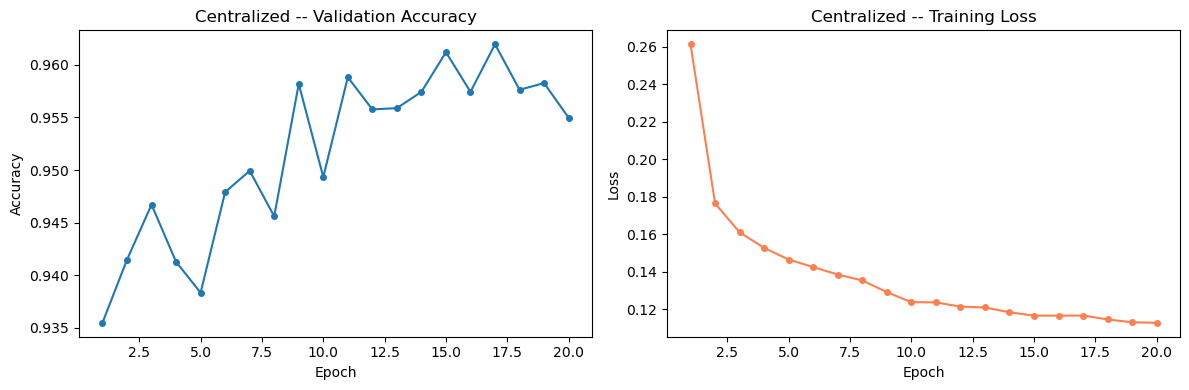

In [21]:
print('=== Centralized Test Results ===')
for k, v in cent_test.items():
    print(f'  {k.title():12s}: {v:.4f}')

if PLOTTING:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(cent_hist['epoch'], cent_hist['val_acc'], marker='o', ms=4)
    axes[0].set(title='Centralized -- Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    axes[1].plot(cent_hist['epoch'], cent_hist['loss'], color='coral', marker='o', ms=4)
    axes[1].set(title='Centralized -- Training Loss', xlabel='Epoch', ylabel='Loss')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_centralized.png', bbox_inches='tight')
    plt.show()

---
## 7 · Federated Training (FedAvg)

In [22]:
def _fedavg_round(parts, global_params, n_features, hidden, adjacency, batch, lr, local_epochs):
    """One FedAvg round: local training on each client, then weighted parameter aggregation."""
    # one model instance reused across all clients — re-initialisation cost paid once per round
    local_model = GCNBiGRU(n_features, hidden=hidden, adjacency=adjacency).to(DEVICE)
    loss_fn     = nn.CrossEntropyLoss()
    client_params, client_sizes = [], []
    for part in parts:
        set_model_params(local_model, global_params)
        loader    = get_loader(part['X'], part['y'], batch, shuffle=True)
        optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)
        for _ in range(local_epochs):
            _train_epoch(local_model, loader, optimizer, loss_fn)
        client_params.append(get_model_params(local_model))
        client_sizes.append(len(part['y']))
    total   = sum(client_sizes)
    weights = [s / total for s in client_sizes]
    agg = []
    for i in range(len(client_params[0])):
        weighted = torch.stack([cp[i].float() * w for cp, w in zip(client_params, weights)])
        agg.append(weighted.sum(dim=0).to(dtype=client_params[0][i].dtype))
    return agg

In [23]:
def run_federated(rounds=ROUNDS, clients=N_CLIENTS, hidden=HIDDEN,
                batch=BATCH, lr=LR, local_epochs=LOCAL_EPOCHS):
    with open(DATA_DIR / 'meta.json') as f:
        meta = json.load(f)
    n_features = meta['n_features']
    adjacency  = torch.tensor(np.load(DATA_DIR / 'adjacency.npy'), dtype=torch.float32)
    with open(DATA_DIR / 'val.pkl', 'rb') as f:
        val = pickle.load(f)
    with open(DATA_DIR / 'test.pkl', 'rb') as f:
        test = pickle.load(f)
    parts = []
    for i in range(clients):
        with open(DATA_DIR / f'client_{i}.pkl', 'rb') as f:
            parts.append(pickle.load(f))

    val_loader    = get_loader(val['X'],  val['y'],  4096, shuffle=False)
    te_loader     = get_loader(test['X'], test['y'], 4096, shuffle=False)
    global_model  = GCNBiGRU(n_features, hidden=hidden, adjacency=adjacency).to(DEVICE)
    global_params = get_model_params(global_model)
    n_params      = sum(np.prod(p.shape) for p in global_params)
    comm_per_round = 2 * clients * n_params * 4   # bytes (float32, upload + download)

    best_val, best_params, history = 0.0, global_params, []
    for rnd in tqdm(range(1, rounds + 1), desc='Federated'):
        global_params = _fedavg_round(
            parts, global_params, n_features, hidden, adjacency, batch, lr, local_epochs)
        set_model_params(global_model, global_params)
        val_acc, val_pr, val_rc, val_f1 = evaluate_model(global_model, val_loader)
        if val_acc > best_val:
            best_val    = val_acc
            best_params = [p.clone() for p in global_params]
        history.append({'round': rnd, 'val_acc': val_acc, 'val_precision': val_pr,
                        'val_recall': val_rc, 'val_f1': val_f1, 'comm_bytes': comm_per_round})
        print(f'  rnd {rnd:02d}: val_acc={val_acc:.4f}  best={best_val:.4f}')

    set_model_params(global_model, best_params)
    te_acc, te_pr, te_rc, te_f1 = evaluate_model(global_model, te_loader)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUT_DIR / 'federated_history.csv', index=False)
    torch.save(global_model.state_dict(), OUT_DIR / 'federated_model.pt')
    test_metrics = {'acc': te_acc, 'precision': te_pr, 'recall': te_rc, 'f1': te_f1}
    with open(OUT_DIR / 'federated_test_metrics.json', 'w') as f:
        json.dump(test_metrics, f)
    print(f'\nBest val acc : {best_val:.4f}  |  Test acc (held-out once): {te_acc:.4f}')
    return hist_df, test_metrics

In [24]:
fed_hist, fed_test = run_federated()

Federated:  10%|█         | 1/10 [00:23<03:33, 23.72s/it]

  rnd 01: val_acc=0.8799  best=0.8799


Federated:  20%|██        | 2/10 [00:46<03:05, 23.24s/it]

  rnd 02: val_acc=0.9198  best=0.9198


Federated:  30%|███       | 3/10 [01:09<02:41, 23.08s/it]

...

Federated:  90%|█████████ | 9/10 [03:26<00:22, 22.78s/it]

  rnd 09: val_acc=0.9495  best=0.9520


Federated: 100%|██████████| 10/10 [03:48<00:00, 22.87s/it]

  rnd 10: val_acc=0.9483  best=0.9520



Best val acc : 0.9520  |  Test acc (held-out once): 0.9502


=== Federated Test Results ===
  Acc         : 0.9502
  Precision   : 0.8915
  Recall      : 0.9343
  F1          : 0.9110


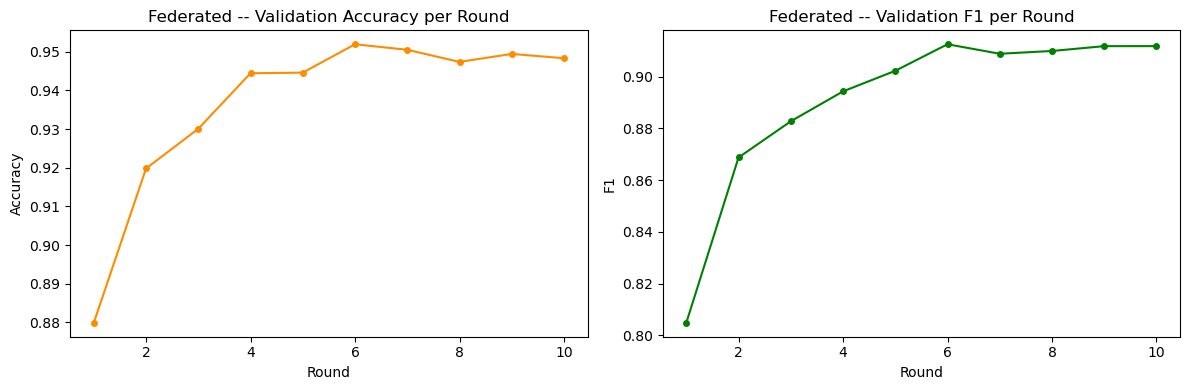

In [25]:
print('=== Federated Test Results ===')
for k, v in fed_test.items():
    print(f'  {k.title():12s}: {v:.4f}')

if PLOTTING:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fed_hist['round'], fed_hist['val_acc'], marker='o', ms=4, color='darkorange')
    axes[0].set(title='Federated -- Validation Accuracy per Round', xlabel='Round', ylabel='Accuracy')
    axes[1].plot(fed_hist['round'], fed_hist['val_f1'], marker='o', ms=4, color='green')
    axes[1].set(title='Federated -- Validation F1 per Round', xlabel='Round', ylabel='F1')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_federated.png', bbox_inches='tight')
    plt.show()

---
## 8 · Results & Comparison

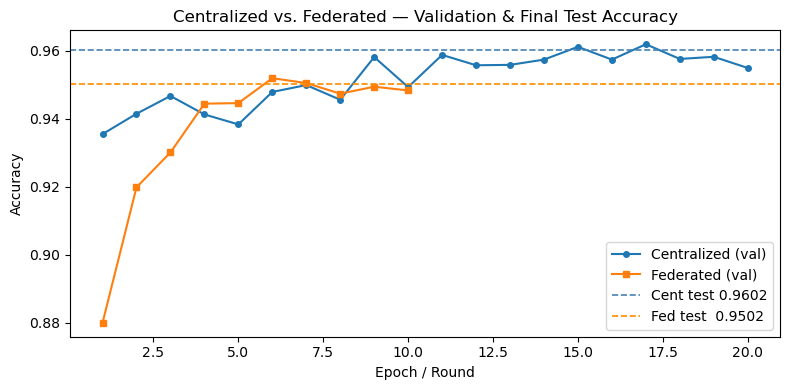

In [26]:
cent = pd.read_csv(OUT_DIR / 'centralized_history.csv')
fed  = pd.read_csv(OUT_DIR / 'federated_history.csv')

if PLOTTING:
    plt.figure(figsize=(8, 4))
    plt.plot(cent['epoch'], cent['val_acc'], label='Centralized (val)', marker='o', ms=4)
    plt.plot(fed['round'],  fed['val_acc'],  label='Federated (val)',   marker='s', ms=4)
    plt.axhline(cent_test['acc'], color='steelblue',  ls='--', lw=1.2,
                label=f"Cent test {cent_test['acc']:.4f}")
    plt.axhline(fed_test['acc'],  color='darkorange', ls='--', lw=1.2,
                label=f"Fed test  {fed_test['acc']:.4f}")
    plt.xlabel('Epoch / Round'); plt.ylabel('Accuracy')
    plt.title('Centralized vs. Federated — Validation & Final Test Accuracy')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_accuracy_comparison.png', bbox_inches='tight')
    plt.show()

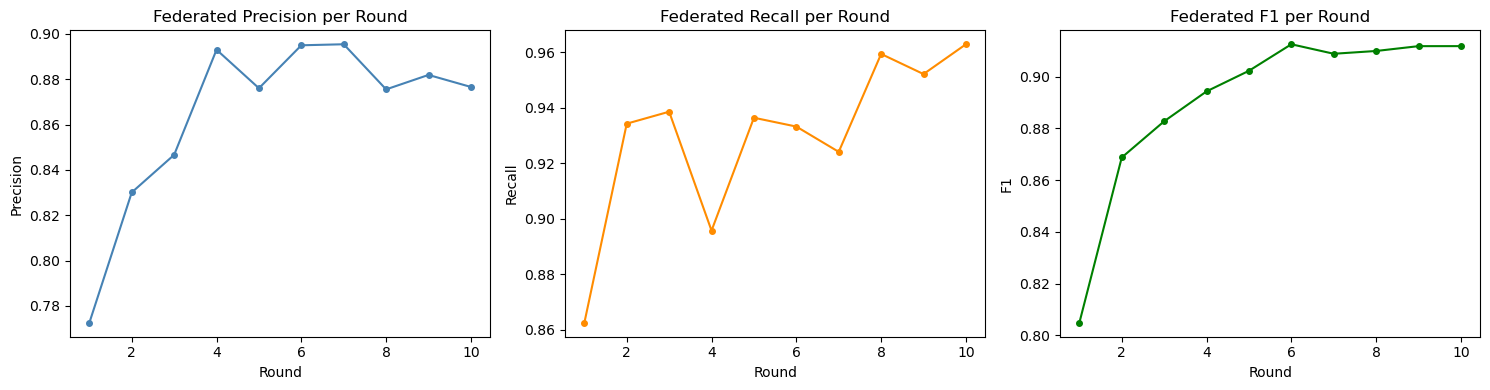

In [27]:
if PLOTTING:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [('val_precision', 'steelblue'), ('val_recall', 'darkorange'), ('val_f1', 'green')]
    for ax, (col, color) in zip(axes, metrics):
        ax.plot(fed['round'], fed[col], color=color, marker='o', ms=4)
        ax.set(title=f"Federated {col.replace('val_', '').title()} per Round",
               xlabel='Round', ylabel=col.replace('val_', '').title())
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_fed_metrics.png', bbox_inches='tight')
    plt.show()

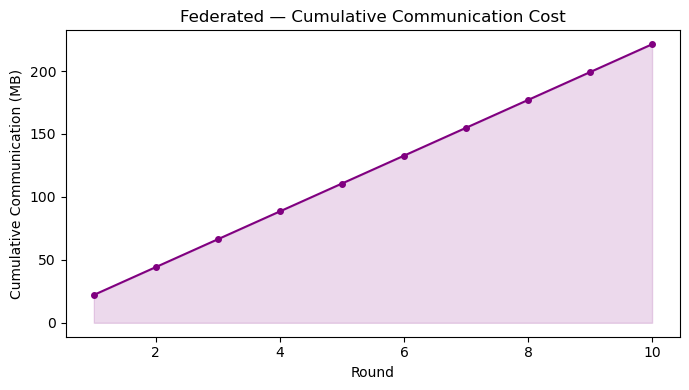

In [28]:
cum_mb = fed['comm_bytes'].cumsum() / (1024 ** 2)

if PLOTTING:
    plt.figure(figsize=(7, 4))
    plt.plot(fed['round'], cum_mb, marker='o', ms=4, color='purple')
    plt.fill_between(fed['round'], cum_mb, alpha=0.15, color='purple')
    plt.xlabel('Round'); plt.ylabel('Cumulative Communication (MB)')
    plt.title('Federated — Cumulative Communication Cost')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_comm.png', bbox_inches='tight')
    plt.show()

In [29]:
summary = pd.DataFrame([
    {'Mode': 'Centralized', **cent_test},
    {'Mode': 'Federated',   **fed_test},
])
for col in ['acc', 'precision', 'recall', 'f1']:
    summary[col] = summary[col].map('{:.4f}'.format)
summary.columns = ['Mode', 'Accuracy', 'Precision', 'Recall', 'F1']
summary.to_csv(OUT_DIR / 'summary.csv', index=False)
print(summary.to_string(index=False))

       Mode Accuracy Precision Recall     F1
Centralized   0.9602    0.9043 0.9625 0.9300
  Federated   0.9502    0.8915 0.9343 0.9110
